<a href="https://colab.research.google.com/github/ananthakrishnanm010/Case_Study_on_Preprocessing/blob/main/Assesment_supervisedLearning_Ananthakrishnan_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mode #for mode operation
from sklearn.preprocessing import MinMaxScaler #scaling numerical data
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression # mutual information library
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,mean_absolute_error, mean_squared_error, r2_score


#Read dataset

In [120]:
filepath = "/content/drive/MyDrive/ICT_Data_Science/heart_disease.csv"
hd_df = pd.read_csv(filepath)

#EDA

In [121]:
hd_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [122]:
print("Number of Rows and Columns:", hd_df.shape)

Number of Rows and Columns: (1025, 14)


In [123]:
hd_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [124]:
hd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [125]:
numerical_cols = hd_df.select_dtypes(include=['int64','float64']).columns

categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Categorical Columns
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


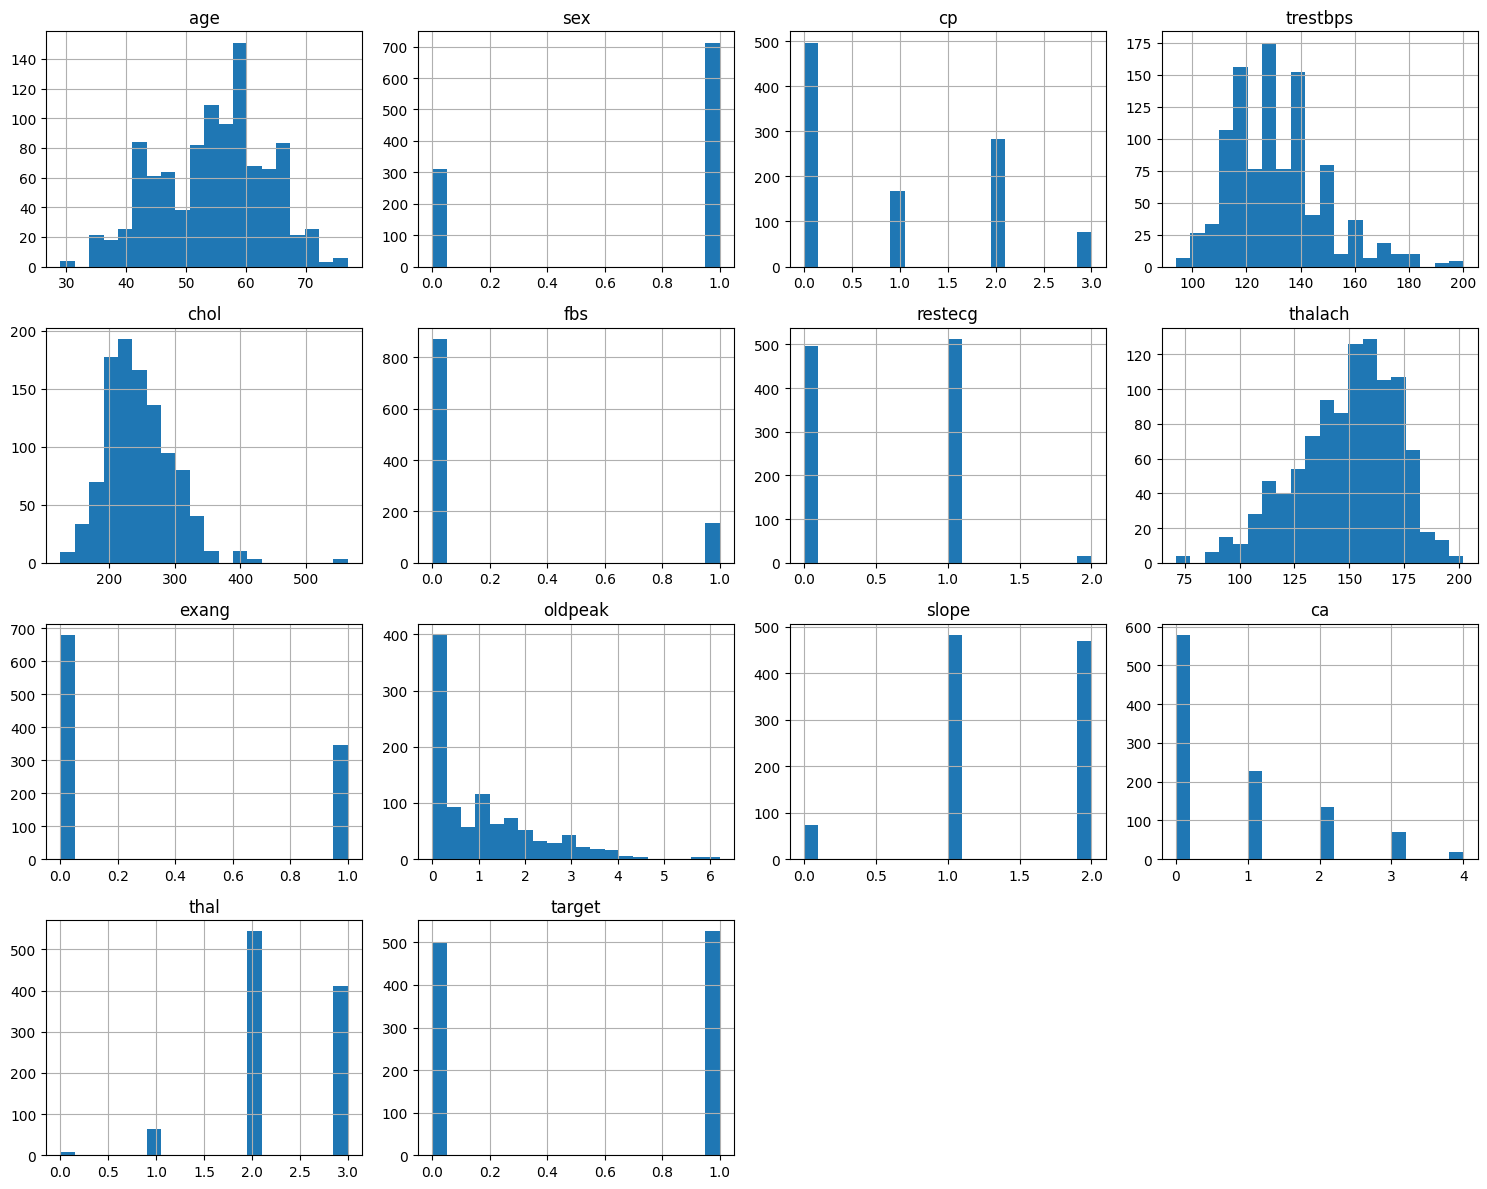

In [126]:
# Histoplot
hd_df[numerical_cols].hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

#Preprocessing

## Data Cleaning

### Duplicate Removal

In [127]:
# Check the number of duplicate rows
hd_df.duplicated().sum()

np.int64(723)

In [128]:
hd_df = hd_df.drop_duplicates()
# After dropping
hd_df.duplicated().sum()

np.int64(0)

### Missing Value Handling

In [129]:
#  missing values
hd_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### Outlier Handling

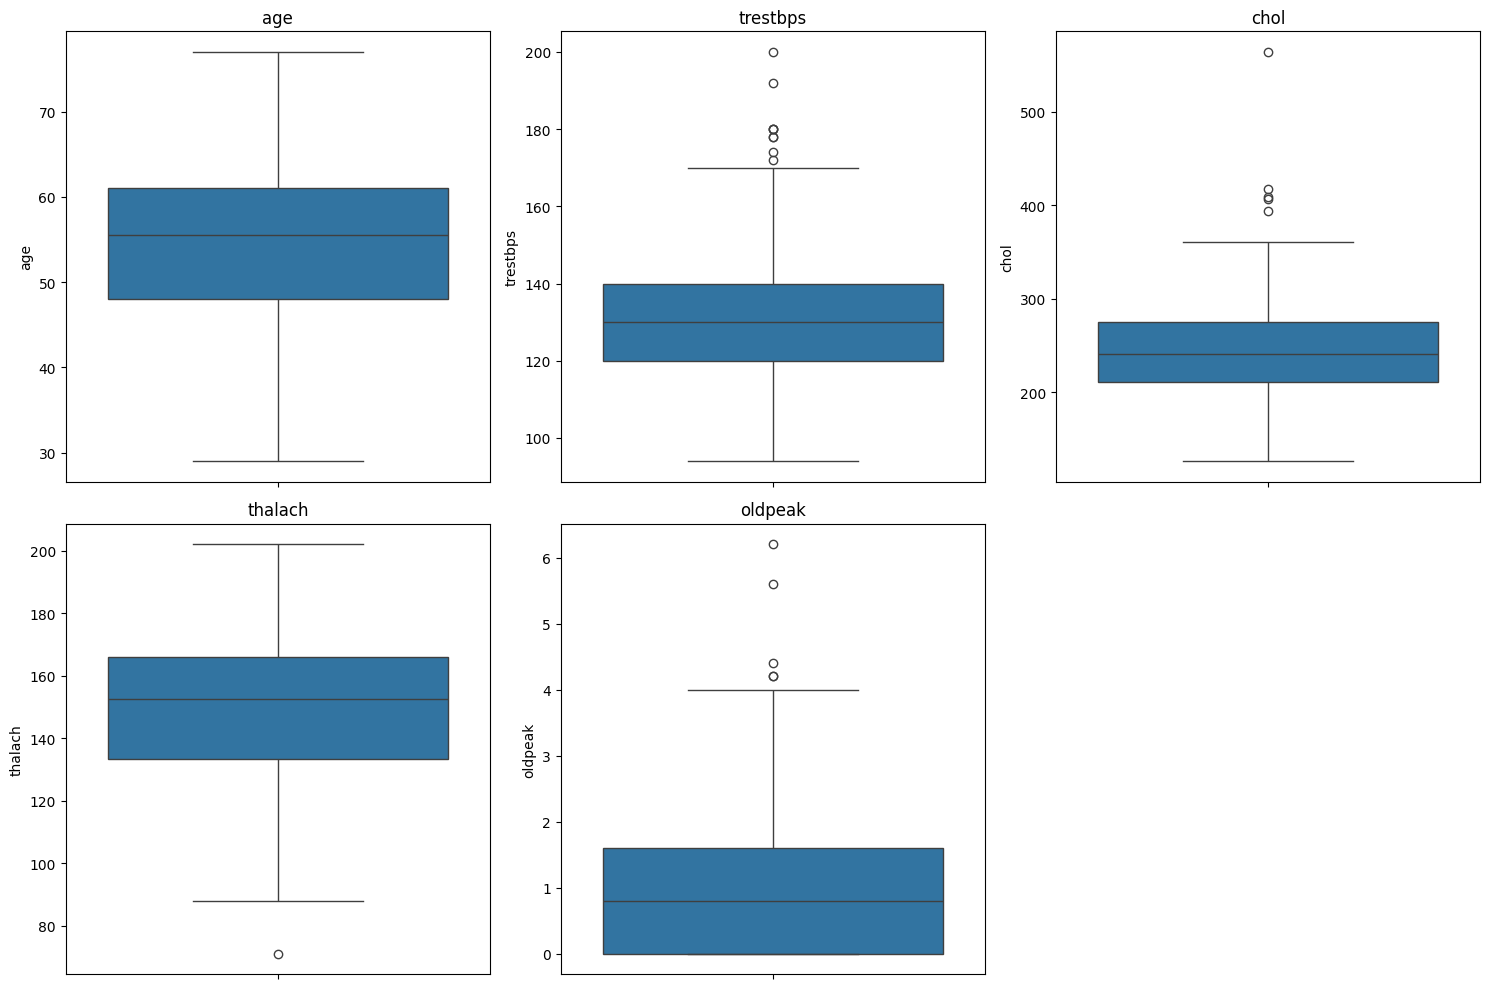

In [130]:
# Box plot before handling outliers
plt.figure(figsize=(15,10))
for i, col in enumerate(['age','trestbps','chol','thalach','oldpeak'], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=hd_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [131]:
def clip_outliers(column):
    Q1 = hd_df[column].quantile(0.25)
    Q3 = hd_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    hd_df[column] = hd_df[column].clip(lower=lower_bound, upper=upper_bound)

In [132]:
for col in ['trestbps', 'chol', 'thalach', 'oldpeak']:
    clip_outliers(col)

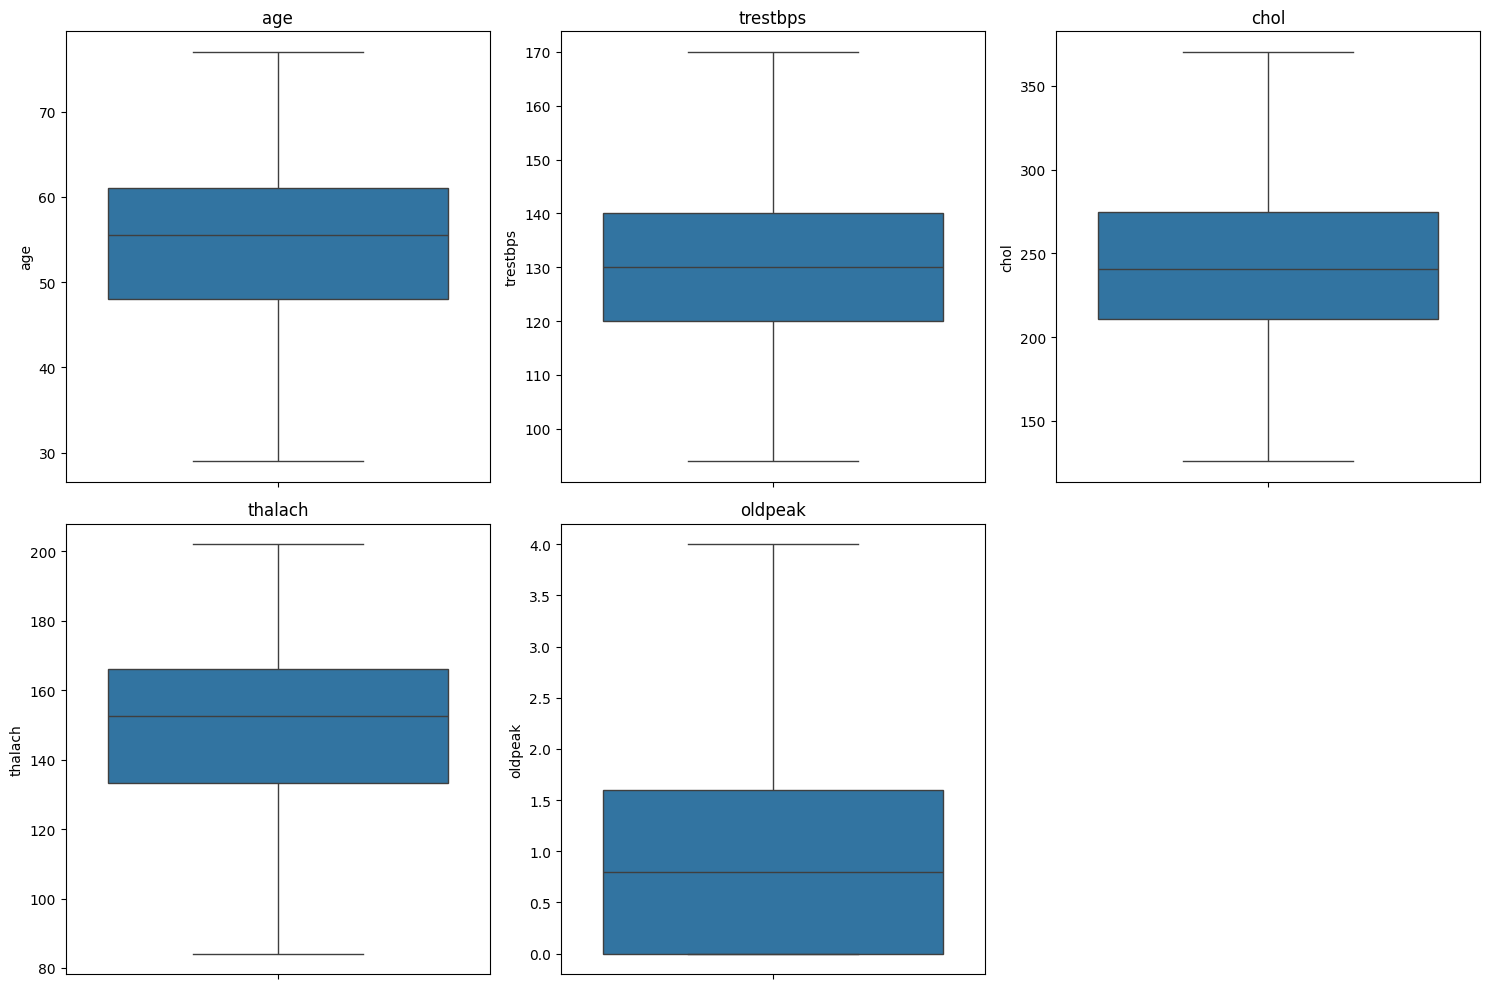

In [133]:
# Box plot after handling outliers
plt.figure(figsize=(15,10))
for i, col in enumerate(['age','trestbps','chol','thalach','oldpeak'], 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=hd_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## For Regression
- we need to split data before scaling the taget 'chol' for classification( since it is a feature in classification)

In [134]:
# Features and Target
X_reg = hd_df.drop('chol', axis=1)
y_reg = hd_df['chol']

# Split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg,y_reg, test_size=0.2, random_state= 42)

scaler = MinMaxScaler()

num_cols1 = ['age', 'trestbps', 'thalach', 'oldpeak']

X_train_reg[num_cols1] = scaler.fit_transform(X_train_reg[num_cols1])
X_test_reg[num_cols1] = scaler.transform(X_test_reg[num_cols1])

##Data Transformation

In [135]:
hd_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53,1,0,140,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62,0,0,138,294.0,1,1,106.0,0,1.9,1,3,2,0


### Encoding

In [136]:
#obj
one_hot_encoder_obj = OneHotEncoder(sparse_output=False)
# transform
encoded_data = one_hot_encoder_obj.fit_transform(hd_df[['cp', 'restecg', 'thal']])
# datafram conversion
encoded_df = pd.DataFrame(encoded_data, columns=one_hot_encoder_obj.get_feature_names_out(['cp', 'restecg', 'thal']),index=hd_df.index)
#dropping original columns
hd_df = hd_df.drop(columns=['cp', 'restecg', 'thal'])
# concatinating
hd_df = pd.concat([hd_df, encoded_df], axis=1)
# encoded df
hd_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212.0,0,168.0,0,1.0,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,140,203.0,1,155.0,1,3.1,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174.0,0,125.0,1,2.6,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203.0,0,161.0,0,0.0,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,0,138,294.0,1,106.0,0,1.9,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


###Scaling

In [137]:
scaler = MinMaxScaler()
scale_cols = ['trestbps', 'chol', 'thalach', 'oldpeak','age']
hd_df[scale_cols] = scaler.fit_transform(hd_df[scale_cols])

#### Log transformation

In [138]:
# Check skewness of numerical columns
hd_df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']].skew()

,0
age,-0.203743
trestbps,0.389876
chol,0.335700
thalach,-0.490122
oldpeak,0.993897


In [139]:
hd_df['oldpeak'] = np.log1p(hd_df['oldpeak'])

## Dataframe after preprocessing

In [140]:
hd_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,0.479167,1,0.407895,0.351918,0,0.711559,0,0.223144,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.500000,1,0.605263,0.315090,1,0.601273,1,0.573800,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.854167,1,0.671053,0.196419,0,0.346766,1,0.500775,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.666667,1,0.710526,0.315090,0,0.652174,0,0.000000,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.687500,0,0.578947,0.687468,1,0.185578,0,0.388658,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Classification

##Data Split

In [141]:
# Spliting
X_class = hd_df.drop("target", axis=1)
y_class= hd_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X_class,y_class, random_state= 42, test_size=0.2)

## Model Building

### Logistic Regression

In [142]:
# Model obj
lr_obj = LogisticRegression()

# Model training
lr_obj.fit(X_train, y_train)

# Model prediction
y_pred = lr_obj.predict(X_test)

In [143]:
# evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7540983606557377
Precision: 0.6944444444444444
Recall   : 0.8620689655172413
F1 Score : 0.7692307692307693


### KNN Classifier

In [144]:
# Model object
knn_obj = KNeighborsClassifier(n_neighbors=5)

# Model training
knn_obj.fit(X_train, y_train)

# Model prediction
y_pred_knn = knn_obj.predict(X_test)

In [145]:
#evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.819672131147541
Precision: 0.75
Recall   : 0.9310344827586207
F1 Score : 0.8307692307692308


### Random Forest Classifier

In [146]:
# Model object
rf_obj = RandomForestClassifier(n_estimators=100, random_state=42)

# Model training
rf_obj.fit(X_train, y_train)

# Model prediction
y_pred_rf = rf_obj.predict(X_test)

In [147]:
#evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.819672131147541
Precision: 0.7647058823529411
Recall   : 0.896551724137931
F1 Score : 0.8253968253968254


# Regression

## Data Split

In [148]:
# splitting done before data transformation

## Model Building

###  Linear Regression

In [149]:
# Model object
ler_obj = LinearRegression()

# Model training
ler_obj.fit(X_train_reg, y_train_reg)

# Model prediction
y_pred_ler = ler_obj.predict(X_test_reg)

In [150]:
# Evaluation
print("MAE :", mean_absolute_error(y_test_reg, y_pred_ler))
print("MSE :", mean_squared_error(y_test_reg, y_pred_ler))
print("R² Score :", r2_score(y_test_reg, y_pred_ler))

MAE : 33.103417850680856
MSE : 1804.9778189218005
R² Score : -0.12808097416990427


###Support Vector Machine

In [151]:
# Model object
svm_obj = SVR()

# Model training
svm_obj.fit(X_train_reg, y_train_reg)

# Model prediction
y_pred_svm = svm_obj.predict(X_test_reg)

In [152]:
# Evaluation
print("MAE :", mean_absolute_error(y_test_reg, y_pred_svm))
print("MSE :", mean_squared_error(y_test_reg, y_pred_svm))
print("R² Score :", r2_score(y_test_reg, y_pred_svm))

MAE : 31.272228244331934
MSE : 1576.6351900876625
R² Score : 0.014629353059269934


### Random Forest Regressor

In [153]:
# Model obj
rf_obj_reg = RandomForestRegressor(n_estimators=100,random_state=42)

# Model training
rf_obj_reg.fit(X_train_reg, y_train_reg)

# Model prediction
y_pred_rf_reg = rf_obj_reg.predict(X_test_reg)

In [154]:
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf_reg))
print("MSE :", mean_squared_error(y_test_reg, y_pred_rf_reg))
print("R² Score :", r2_score(y_test_reg, y_pred_rf_reg))

MAE : 33.016905737704924
MSE : 1795.3815145747951
R² Score : -0.12208344431512352
